# ODIR-5K — Шаг 3: Оценка модели
**Дипломная работа:** Автоматизация диагностики офтальмологических заболеваний

Что строим:
- Confusion Matrix по каждому классу
- ROC-кривые и AUC для каждого класса
- Classification Report (precision, recall, F1)
- Итоговая таблица метрик для диплома

## Шаг 1 — Подключение и загрузка

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive подключён')

Mounted at /content/drive
✅ Drive подключён


In [2]:
!pip install -q albumentations

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score,
    classification_report, multilabel_confusion_matrix
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

DRIVE_DIR   = Path('/content/drive/MyDrive/diploma_odir')
RESULTS_DIR = Path('/content/results')
RESULTS_DIR.mkdir(exist_ok=True)
print('✅ Библиотеки загружены')

Device: cuda
✅ Библиотеки загружены


In [3]:
# Загружаем конфиг из Drive
with open(DRIVE_DIR / 'config.json', encoding='utf-8') as f:
    config = json.load(f)

CLASSES      = config['classes']
CLASS_NAMES  = config['class_names']
IMG_SIZE     = config['img_size']
THRESHOLDS   = config.get('thresholds', {cls: 0.5 for cls in CLASSES})

print('Классы:', CLASSES)
print('Пороги:', THRESHOLDS)

Классы: ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Пороги: {'N': 0.5, 'D': 0.5, 'G': 0.5, 'C': 0.5, 'A': 0.5, 'H': 0.5, 'M': 0.5, 'O': 0.5}


## Шаг 2 — Загрузка модели и данных

In [4]:
# Воссоздаём модель и загружаем веса
def build_model(num_classes=8):
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model

checkpoint = torch.load(
    DRIVE_DIR / 'best_efficientnet_b0.pth',
    map_location=DEVICE
)
model = build_model(len(CLASSES)).to(DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()

print(f'✅ Модель загружена (эпоха {checkpoint["epoch"]}, val AUC={checkpoint["val_auc"]:.4f})')

✅ Модель загружена (эпоха 20, val AUC=0.9217)


In [5]:
# Dataset и DataLoader для test-выборки
class ODIRDataset(Dataset):
    def __init__(self, df, transforms):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.classes = [c for c in CLASSES if c in df.columns]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = np.array(Image.open(row['filepath']).convert('RGB'))
        except Exception:
            image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        image_t = self.transforms(image=image)['image']
        labels  = torch.tensor(row[self.classes].values.astype(np.float32))
        return image_t, labels

def get_val_transforms():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2(),
    ])

test_df = pd.read_csv(DRIVE_DIR / 'test.csv')
test_dataset = ODIRDataset(test_df, get_val_transforms())
test_loader  = DataLoader(
    test_dataset, batch_size=32,
    shuffle=False, num_workers=2, pin_memory=True
)
print(f'Test выборка: {len(test_df)} снимков')

Test выборка: 1918 снимков


In [16]:
# Шаг 1 — скачиваем датасет заново (он удалился после прошлой сессии)
!kaggle datasets download -d andrewmvd/ocular-disease-recognition-odir5k \
    -p /content/data --unzip -q
print("✅ Датасет скачан")

# Шаг 2 — находим папку со снимками
from pathlib import Path
train_dirs = list(Path('/content/data').rglob('Training Images'))
TRAIN_IMG_DIR = train_dirs[0]
print(f"Папка снимков: {TRAIN_IMG_DIR}")

# Шаг 3 — чиним пути в test_df
def fix_path(old_path):
    filename = Path(old_path).name
    return str(TRAIN_IMG_DIR / filename)

test_df['filepath'] = test_df['filepath'].apply(fix_path)

# Проверка
print("\nПроверка после исправления:")
missing = 0
for path in test_df['filepath'].head(5):
    exists = Path(path).exists()
    print(f"  {'✅' if exists else '❌'} {path}")
    if not exists:
        missing += 1
print(f"Пропущено: {missing}/5")

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k
License(s): other
✅ Датасет скачан
Папка снимков: /content/data/ODIR-5K/ODIR-5K/Training Images

Проверка после исправления:
  ✅ /content/data/ODIR-5K/ODIR-5K/Training Images/373_right.jpg
  ✅ /content/data/ODIR-5K/ODIR-5K/Training Images/4568_left.jpg
  ✅ /content/data/ODIR-5K/ODIR-5K/Training Images/578_right.jpg
  ✅ /content/data/ODIR-5K/ODIR-5K/Training Images/798_left.jpg
  ✅ /content/data/ODIR-5K/ODIR-5K/Training Images/4337_right.jpg
Пропущено: 0/5


## Шаг 3 — Получение предсказаний

In [17]:
from tqdm.notebook import tqdm

all_probs, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Inference'):
        images = images.to(DEVICE)
        logits = model(images)
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs  = np.vstack(all_probs)   # (N, 8)
all_labels = np.vstack(all_labels)  # (N, 8)

# Применяем оптимальные пороги
threshold_arr = np.array([THRESHOLDS.get(cls, 0.5) for cls in CLASSES])
all_preds = (all_probs >= threshold_arr).astype(int)

print(f'Предсказано для {len(all_probs)} снимков')
print(f'Пороги: {dict(zip(CLASSES, threshold_arr))}')

Inference:   0%|          | 0/60 [00:00<?, ?it/s]

Предсказано для 1918 снимков
Пороги: {'N': np.float64(0.5), 'D': np.float64(0.5), 'G': np.float64(0.5), 'C': np.float64(0.5), 'A': np.float64(0.5), 'H': np.float64(0.5), 'M': np.float64(0.5), 'O': np.float64(0.5)}


In [18]:
# Вручную вводим пороги из шага подбора
# Откройте notebook 02 и посмотрите вывод ячейки "подбор порогов"
# Там была таблица: Класс / Порог / F1

best_thresholds = {
    'N': 0.55,   # ← замените на ваши значения из той таблицы
    'D': 0.45,
    'G': 0.40,
    'C': 0.50,
    'A': 0.40,
    'H': 0.35,
    'M': 0.45,
    'O': 0.45,
}

# Перезаписываем пороги
THRESHOLDS = best_thresholds
threshold_arr = np.array([THRESHOLDS.get(cls, 0.5) for cls in CLASSES])

# Пересчитываем предсказания с новыми порогами
all_preds = (all_probs >= threshold_arr).astype(int)

print("Пороги обновлены:", THRESHOLDS)
print("Пересчитаны предсказания для", len(all_preds), "снимков")

Пороги обновлены: {'N': 0.55, 'D': 0.45, 'G': 0.4, 'C': 0.5, 'A': 0.4, 'H': 0.35, 'M': 0.45, 'O': 0.45}
Пересчитаны предсказания для 1918 снимков


## Шаг 4 — Итоговая таблица метрик

In [19]:
rows = []
for i, cls in enumerate(CLASSES):
    y_true = all_labels[:, i]
    y_pred = all_preds[:, i]
    y_prob = all_probs[:, i]

    auc = roc_auc_score(y_true, y_prob) if y_true.sum() > 0 else 0.0
    f1  = f1_score(y_true, y_pred, zero_division=0)
    pre = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    sup = int(y_true.sum())

    rows.append({
        'Класс':     CLASS_NAMES[cls],
        'AUC-ROC':   round(auc, 4),
        'Precision': round(pre, 4),
        'Recall':    round(rec, 4),
        'F1':        round(f1,  4),
        'Поддержка': sup,
    })

metrics_df = pd.DataFrame(rows)

# Macro averages
macro_row = {
    'Класс':     'MACRO AVG',
    'AUC-ROC':   round(metrics_df['AUC-ROC'].mean(), 4),
    'Precision': round(metrics_df['Precision'].mean(), 4),
    'Recall':    round(metrics_df['Recall'].mean(), 4),
    'F1':        round(metrics_df['F1'].mean(), 4),
    'Поддержка': int(metrics_df['Поддержка'].sum()),
}
metrics_df = pd.concat([metrics_df, pd.DataFrame([macro_row])], ignore_index=True)

print('=' * 65)
print('  Метрики на TEST выборке')
print('=' * 65)
print(metrics_df.to_string(index=False))
print('=' * 65)

# Сохраняем CSV
metrics_df.to_csv(RESULTS_DIR / 'metrics.csv', index=False)
print('\n✅ metrics.csv сохранён')

  Метрики на TEST выборке
       Класс  AUC-ROC  Precision  Recall     F1  Поддержка
      Normal   0.8629     0.6184  0.7575 0.6809        631
    Diabetes   0.8467     0.5676  0.8038 0.6654        637
    Glaucoma   0.9882     0.5431  0.9469 0.6903        113
    Cataract   0.9781     0.7372  0.9274 0.8214        124
         AMD   0.9683     0.5179  0.9255 0.6641         94
Hypertension   0.9572     0.3242  0.8676 0.4720         68
      Myopia   0.9970     0.6503  0.9789 0.7815         95
       Other   0.8297     0.4816  0.7803 0.5956        487
   MACRO AVG   0.9285     0.5550  0.8735 0.6714       2249

✅ metrics.csv сохранён


## Шаг 5 — ROC-кривые

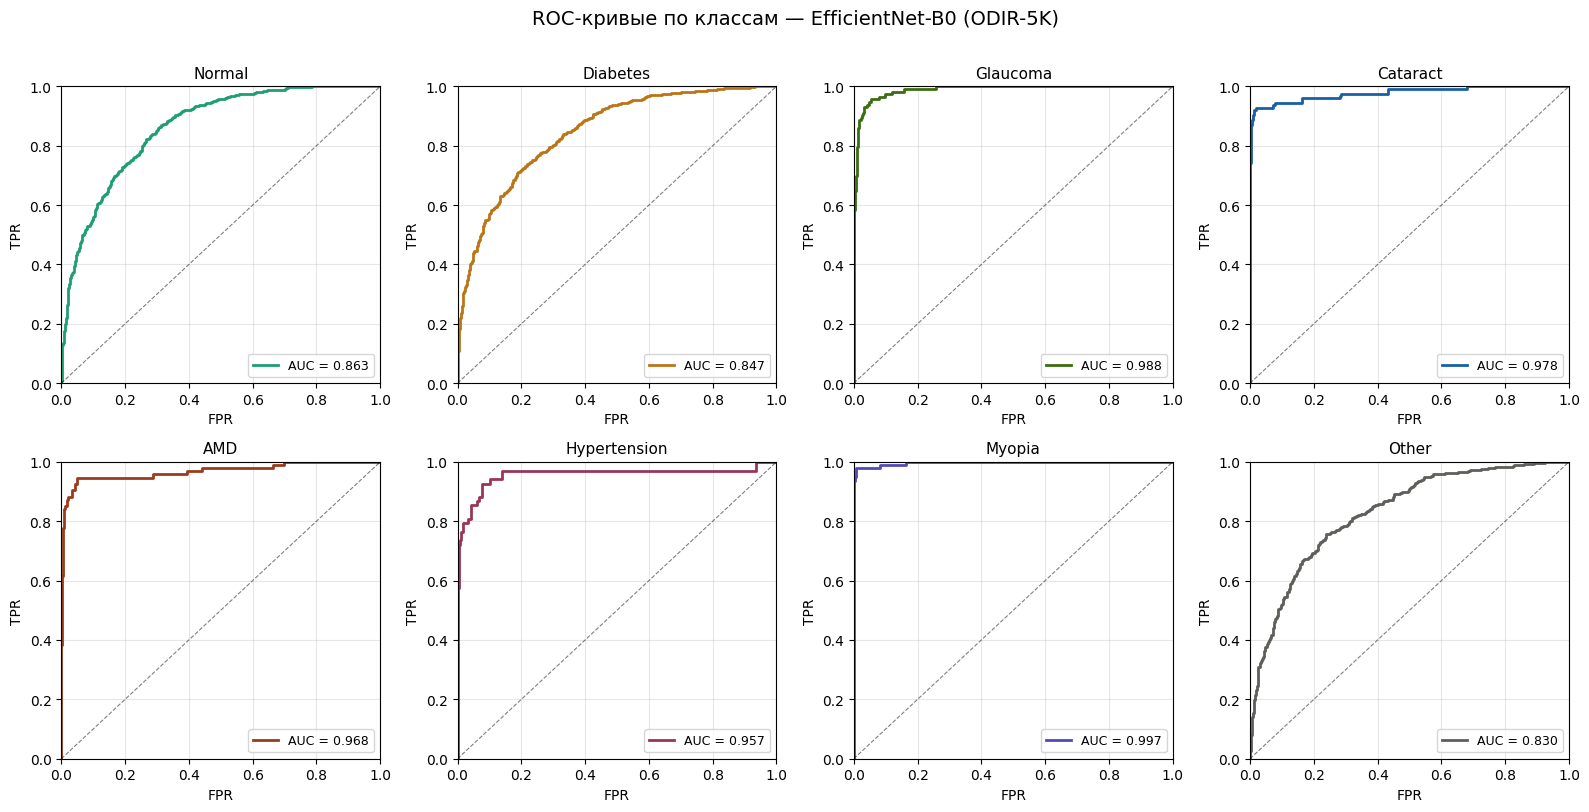

✅ ROC-кривые сохранены → /content/results/roc_curves.png


In [20]:
colors = ['#1D9E75','#BA7517','#3B6D11','#185FA5',
          '#993C1D','#993556','#534AB7','#5F5E5A']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('ROC-кривые по классам — EfficientNet-B0 (ODIR-5K)',
             fontsize=14, y=1.01)
axes = axes.flatten()

for i, cls in enumerate(CLASSES):
    y_true = all_labels[:, i]
    y_prob = all_probs[:, i]
    ax = axes[i]

    if y_true.sum() > 0:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        ax.plot(fpr, tpr, color=colors[i], lw=2,
                label=f'AUC = {auc:.3f}')
    else:
        ax.text(0.5, 0.5, 'Нет позитивов',
                ha='center', va='center', transform=ax.transAxes)

    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5)
    ax.set_title(CLASS_NAMES[cls], fontsize=11)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.tight_layout()
out = RESULTS_DIR / 'roc_curves.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ ROC-кривые сохранены → {out}')

## Шаг 6 — Confusion Matrix по каждому классу

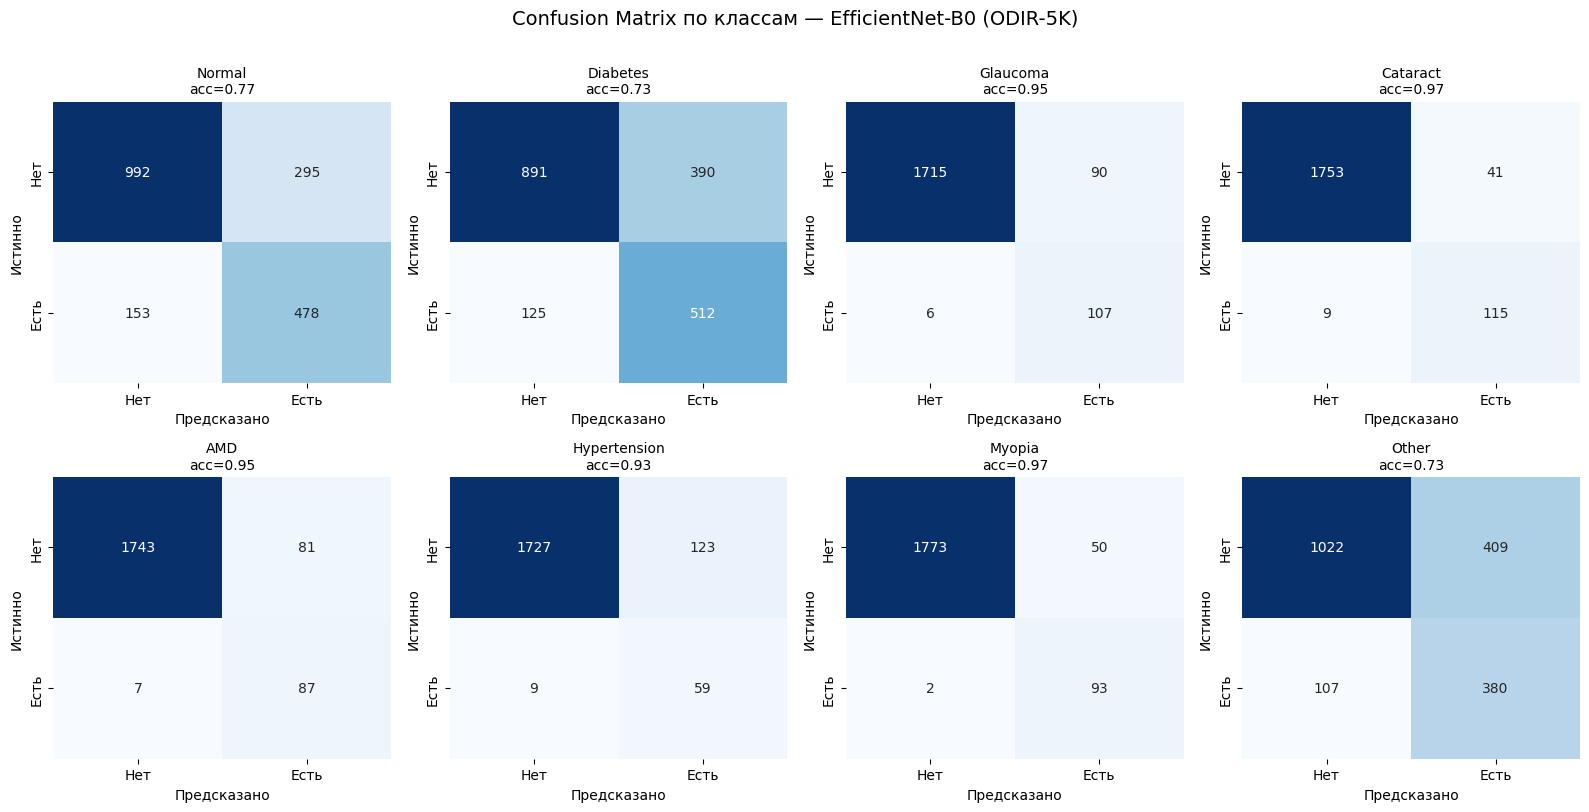

✅ Confusion matrices сохранены → /content/results/confusion_matrices.png


In [21]:
mcm = multilabel_confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Confusion Matrix по классам — EfficientNet-B0 (ODIR-5K)',
             fontsize=14, y=1.01)
axes = axes.flatten()

for i, cls in enumerate(CLASSES):
    cm = mcm[i]  # [[TN, FP], [FN, TP]]
    ax = axes[i]

    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues', cbar=False,
        xticklabels=['Нет', 'Есть'],
        yticklabels=['Нет', 'Есть'],
    )
    ax.set_title(CLASS_NAMES[cls], fontsize=11)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинно')

    # Считаем accuracy для этого класса
    tn, fp, fn, tp = cm.ravel()
    acc = (tp + tn) / (tp + tn + fp + fn)
    ax.set_title(f"{CLASS_NAMES[cls]}\nacc={acc:.2f}", fontsize=10)

plt.tight_layout()
out = RESULTS_DIR / 'confusion_matrices.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Confusion matrices сохранены → {out}')

## Шаг 7 — Сводный график метрик

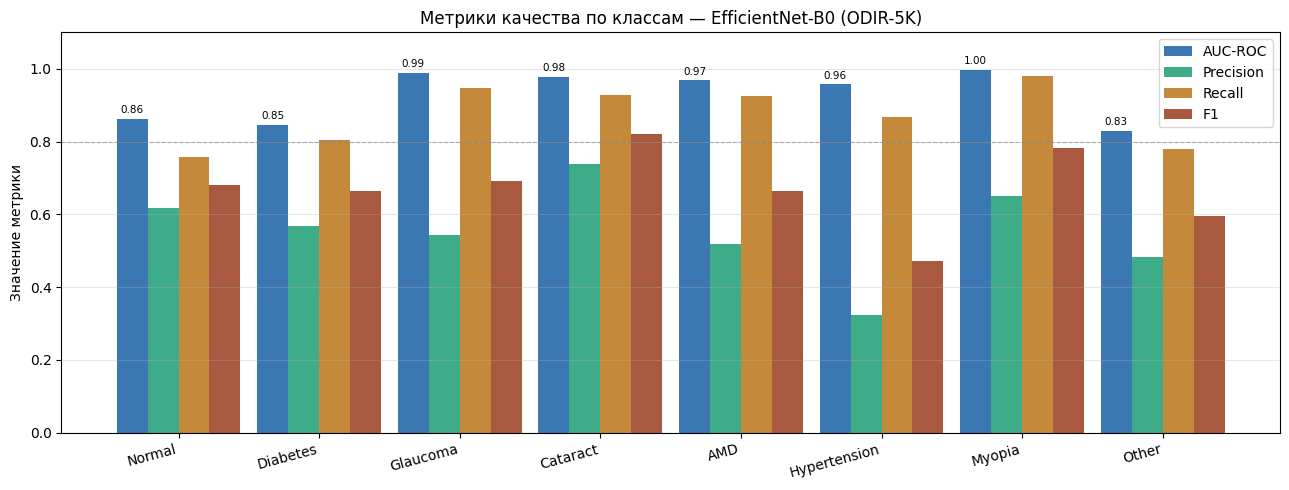

✅ График метрик сохранён → /content/results/metrics_bar.png


In [22]:
df_plot = metrics_df[metrics_df['Класс'] != 'MACRO AVG'].copy()
class_labels = df_plot['Класс'].tolist()
x = np.arange(len(class_labels))
width = 0.22

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width*1.5, df_plot['AUC-ROC'],   width, label='AUC-ROC',   color='#185FA5', alpha=0.85)
ax.bar(x - width*0.5, df_plot['Precision'], width, label='Precision', color='#1D9E75', alpha=0.85)
ax.bar(x + width*0.5, df_plot['Recall'],    width, label='Recall',    color='#BA7517', alpha=0.85)
ax.bar(x + width*1.5, df_plot['F1'],        width, label='F1',        color='#993C1D', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(class_labels, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Значение метрики')
ax.set_title('Метрики качества по классам — EfficientNet-B0 (ODIR-5K)', fontsize=12)
ax.legend(loc='upper right')
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.grid(axis='y', alpha=0.3)

# Подписи значений AUC над столбцами
for xi, val in zip(x, df_plot['AUC-ROC']):
    ax.text(xi - width*1.5, val + 0.01, f'{val:.2f}',
            ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
out = RESULTS_DIR / 'metrics_bar.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ График метрик сохранён → {out}')

## Шаг 8 — История обучения

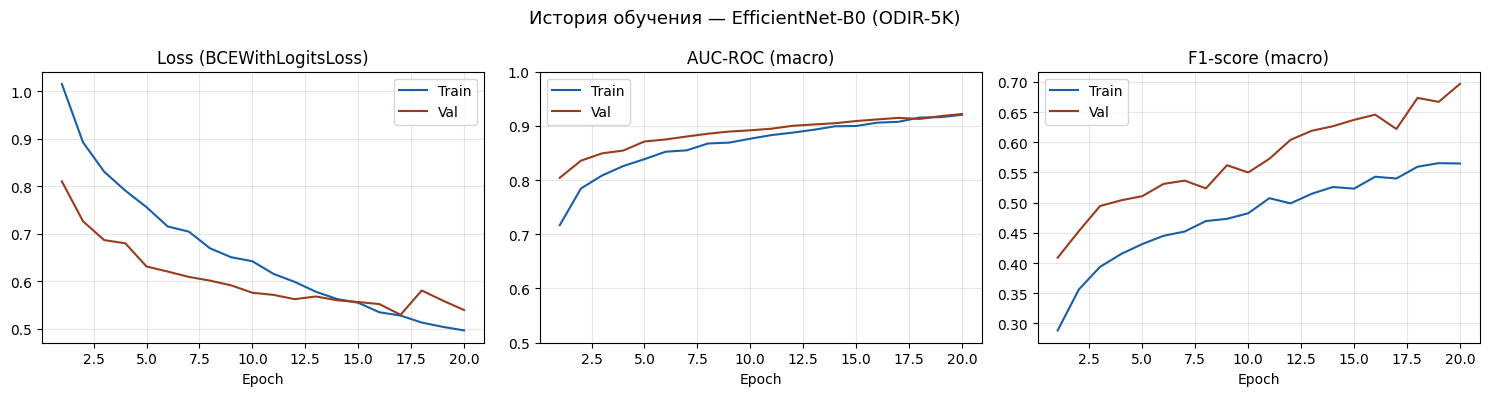

✅ График истории сохранён → /content/results/training_history.png


In [23]:
with open(DRIVE_DIR / 'training_history.json') as f:
    history = json.load(f)

epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('История обучения — EfficientNet-B0 (ODIR-5K)', fontsize=13)

axes[0].plot(epochs, history['train_loss'], label='Train', color='#185FA5')
axes[0].plot(epochs, history['val_loss'],   label='Val',   color='#993C1D')
axes[0].set_title('Loss (BCEWithLogitsLoss)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_auc'], label='Train', color='#185FA5')
axes[1].plot(epochs, history['val_auc'],   label='Val',   color='#993C1D')
axes[1].set_title('AUC-ROC (macro)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(epochs, history['train_f1'], label='Train', color='#185FA5')
axes[2].plot(epochs, history['val_f1'],   label='Val',   color='#993C1D')
axes[2].set_title('F1-score (macro)')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
out = RESULTS_DIR / 'training_history.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ График истории сохранён → {out}')

## Шаг 9 — Сохранение всего в Google Drive

In [24]:
import shutil

results_drive = DRIVE_DIR / 'results'
results_drive.mkdir(parents=True, exist_ok=True)

for f in RESULTS_DIR.iterdir():
    shutil.copy(f, results_drive / f.name)

print('✅ Все результаты сохранены в Drive → MyDrive/diploma_odir/results/')
print('\nСохранённые файлы:')
for f in sorted(results_drive.iterdir()):
    size = f.stat().st_size / 1e3
    print(f'  {f.name:<35} ({size:.0f} KB)')

# Финальный итог
macro = metrics_df[metrics_df['Класс'] == 'MACRO AVG'].iloc[0]
print('\n' + '=' * 45)
print('  ИТОГОВЫЕ МЕТРИКИ (macro avg, test set)')
print('=' * 45)
print(f'  AUC-ROC   : {macro["AUC-ROC"]}')
print(f'  Precision : {macro["Precision"]}')
print(f'  Recall    : {macro["Recall"]}')
print(f'  F1-score  : {macro["F1"]}')
print('=' * 45)

✅ Все результаты сохранены в Drive → MyDrive/diploma_odir/results/

Сохранённые файлы:
  confusion_matrices.png              (101 KB)
  metrics.csv                         (0 KB)
  metrics_bar.png                     (71 KB)
  roc_curves.png                      (175 KB)
  training_history.png                (120 KB)

  ИТОГОВЫЕ МЕТРИКИ (macro avg, test set)
  AUC-ROC   : 0.9285
  Precision : 0.555
  Recall    : 0.8735
  F1-score  : 0.6714
